✅ Using PROJECT_ROOT: D:\EDUSign
✅ Found model: D:\EDUSign\models\sign_cnn.h5
✅ Found labels: D:\EDUSign\models\labels.npy
✅ Found dataset: D:\EDUSign\data\processed\landmarks_full_dataset.npz
✅ Loaded labels: 27
✅ Loaded dataset
X: (13606, 63) y: (13606,)
✅ Encoded labels
Final X: (13606, 63) | Num classes present: 27
✅ Split done
Train: (10884, 63) (10884,)
Test : (2722, 63) (2722,)
✅ Loaded model
86/86 [==============================] - 1s 3ms/step


<Figure size 1000x1000 with 0 Axes>

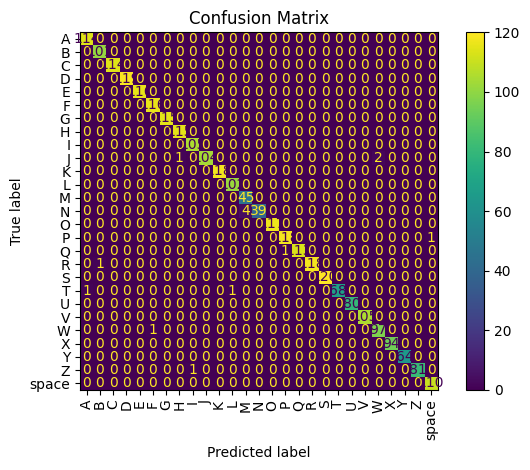

✅ Saved confusion matrix: D:\EDUSign\results\confusion_matrix.png

✅ Classification Report:

              precision    recall  f1-score   support

           A       0.99      1.00      1.00       114
           B       0.99      1.00      1.00       101
           C       1.00      1.00      1.00       114
           D       1.00      1.00      1.00       119
           E       1.00      1.00      1.00       116
           F       0.99      1.00      1.00       116
           G       1.00      1.00      1.00       115
           H       0.99      1.00      1.00       115
           I       0.99      1.00      1.00       105
           J       1.00      0.97      0.99       107
           K       1.00      1.00      1.00       118
           L       0.99      1.00      1.00       102
           M       0.92      1.00      0.96        45
           N       1.00      0.91      0.95        43
           O       1.00      1.00      1.00       117
           P       0.99      0.99      0.9

In [ ]:

# restart the project 


import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1) Paths
PROJECT_ROOT = r"D:\EDUSign"
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

model_file = os.path.join(MODELS_DIR, "sign_cnn.h5")
labels_file = os.path.join(MODELS_DIR, "labels.npy")
dataset_file = os.path.join(DATA_PROCESSED, "landmarks_full_dataset.npz")

print("✅ Using PROJECT_ROOT:", PROJECT_ROOT)

# 2) Check required files
missing = []
for f in [model_file, labels_file, dataset_file]:
    if not os.path.exists(f):
        missing.append(f)

if missing:
    raise FileNotFoundError("❌ Missing required file(s):\n" + "\n".join(missing))

print("✅ Found model:", model_file)
print("✅ Found labels:", labels_file)
print("✅ Found dataset:", dataset_file)

# 3) Load labels (best practice)
CLASSES = np.load(labels_file, allow_pickle=True).tolist()
print("✅ Loaded labels:", len(CLASSES))

# 4) Load dataset
data = np.load(dataset_file, allow_pickle=True)
X = data["X"]
y = data["y"]

print("✅ Loaded dataset")
print("X:", X.shape, "y:", y.shape)

# 5) Encode y using the saved labels (ensures consistency with trained model)
label_to_index = {label: i for i, label in enumerate(CLASSES)}

# Keep only samples that exist in labels.npy (in case dataset has extra classes)
mask = np.array([lbl in label_to_index for lbl in y], dtype=bool)
X = X[mask]
y = y[mask]

y_idx = np.array([label_to_index[lbl] for lbl in y], dtype=np.int32)

print("✅ Encoded labels")
print("Final X:", X.shape, "| Num classes present:", len(np.unique(y_idx)))

# 6) Train/Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_idx, test_size=0.2, random_state=42, stratify=y_idx
)

print("✅ Split done")
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

# 7) Load trained model
model = tf.keras.models.load_model(model_file)
print("✅ Loaded model")

# 8) Predict + confusion matrix (safe plotting)
y_pred = np.argmax(model.predict(X_test), axis=1)

present_ids = np.unique(np.concatenate([y_test, y_pred]))
present_ids = np.sort(present_ids)
present_labels = [CLASSES[i] for i in present_ids]

cm = confusion_matrix(y_test, y_pred, labels=present_ids)
disp = ConfusionMatrixDisplay(cm, display_labels=present_labels)

plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()

cm_path = os.path.join(RESULTS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("✅ Saved confusion matrix:", cm_path)
print("\n✅ Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=present_labels))


In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))



[]


In [4]:
import tensorflow as tf
tf.debugging.set_log_device_placement(True)

a = tf.constant([[1.0, 2.0]])
b = tf.constant([[3.0, 4.0]])
c = tf.matmul(a, b)
print(c)


InvalidArgumentError: {{function_node __wrapped__MatMul_device_/job:localhost/replica:0/task:0/device:CPU:0}} Matrix size-incompatible: In[0]: [1,2], In[1]: [1,2] [Op:MatMul]

In [5]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

NameError: name 'history' is not defined

In [6]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32
)

NameError: name 'X_val' is not defined